In [33]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [34]:
# %%
FONT_SIZE = 8
plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.transparent': True,
    'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
    'font.size': FONT_SIZE, 'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE, 'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE, 'legend.fontsize': FONT_SIZE,
})

In [35]:
# %%
# Load forward TRFs for all subjects
SUBJECTS = helper_functions.get_subjects()

checks = [
    # Single predictors
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, True),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, True),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),

    # Multiple predictors
    ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False),
    ([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False),
]

trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=MAT_FILE_TRF_DIR)

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects


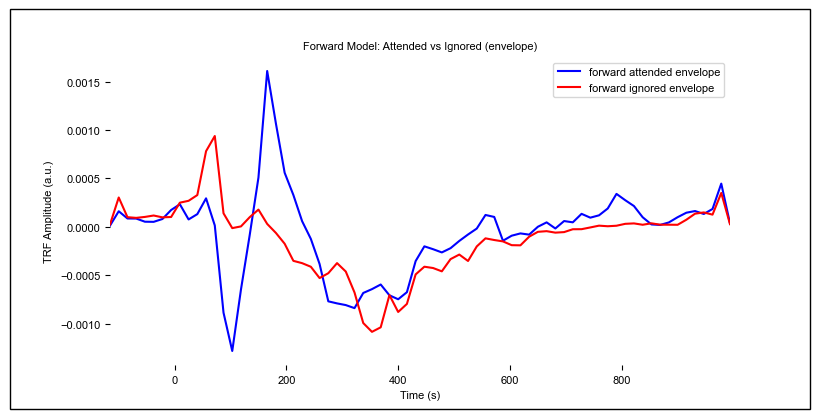

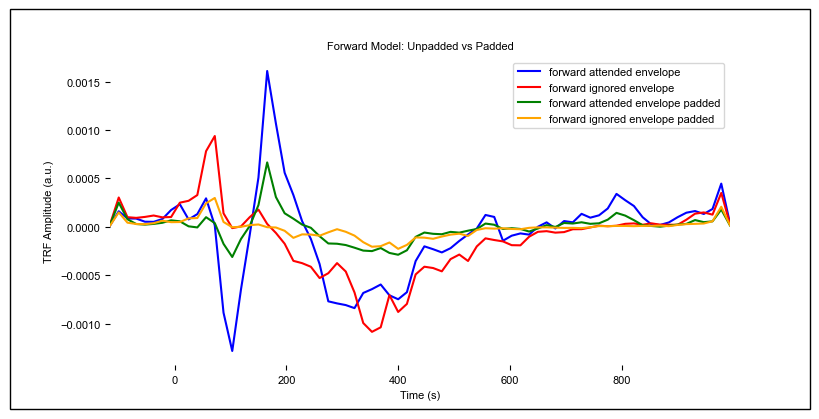

In [36]:
# %%
# Grand mean TRF plot — envelope attended vs ignored (unpadded)
def plot_grand_mean(checks_subset, title, filename):
    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw=dict(frame_on=False))
    colors = ['blue', 'red', 'green', 'orange']
    labels = []
    grands = []

    for (p, a, m, pad), color in zip(checks_subset, colors):
        name  = helper_functions.get_trf_model_name(p, a, m, pad)
        means = [trf.h.mean('sensor') for trf in trf_data[name]]
        grand = eelbrain.combine(means).mean('case')
        eelbrain.plot.UTS(grand, axes=ax, color=color)
        labels.append(name.replace('_', ' '))
        grands.append(grand)

    ymin   = min(g.x.min() for g in grands)
    ymax   = max(g.x.max() for g in grands)
    margin = 0.05 * (ymax - ymin)
    ax.set_ylim(ymin - margin, ymax + margin)

    ax.legend(labels, loc='upper right')
    ax.set_title(title)
    ax.set_ylabel('TRF Amplitude (a.u.)')
    ax.set_xlabel('Time (s)')
    eelbrain.plot.figure_outline()
    fig.savefig(FIGURES_DIR / filename, bbox_inches='tight')
    plt.show()

plot_grand_mean(checks[:2], 'Forward Model: Attended vs Ignored (envelope)', 'forward_att_vs_ign.png')
plot_grand_mean(checks[:4], 'Forward Model: Unpadded vs Padded', 'forward_padded_comparison.png')


In [37]:
# %%
# Extract mean r per subject for each condition
def mean_r(name):
    return [trf.r.mean() for trf in trf_data[name]]

r = {
     helper_functions.get_trf_model_name(p, a, m, pad): mean_r(helper_functions.get_trf_model_name(p, a, m, pad))
     for p, a, m, pad in checks
}

names = list(r.keys())


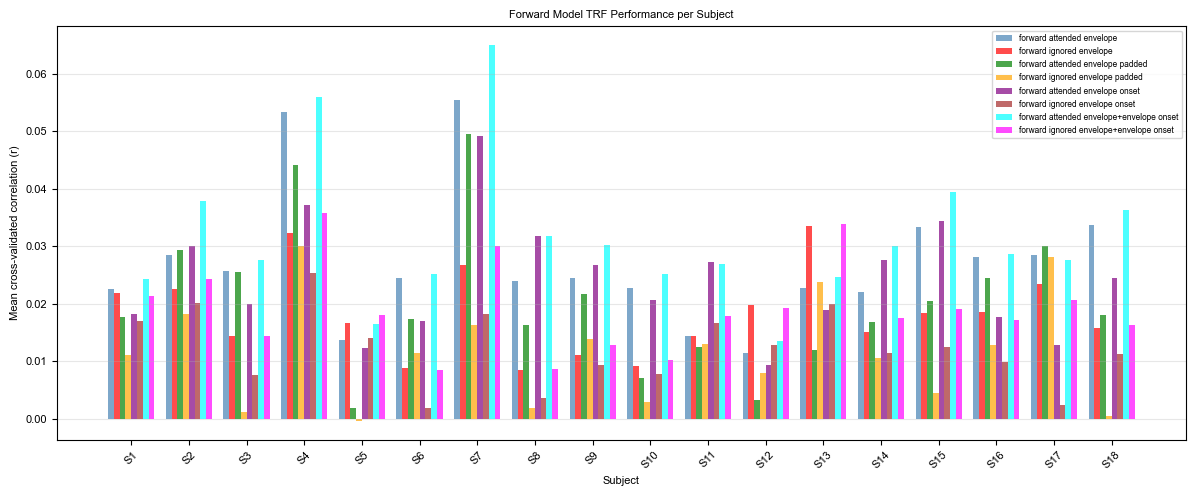

In [38]:
# %%
# Per-subject bar plot
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(n_subjects)
width = 0.1
colors = ['steelblue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']

for i, (name, color) in enumerate(zip(names, colors)):
    offset = (i - len(names)/2 + 0.5) * width
    ax.bar(x + offset, r[name], width, color=color, alpha=0.7, label=name.replace('_', ' '))

ax.set_xlabel('Subject')
ax.set_ylabel('Mean cross-validated correlation (r)')
ax.set_title('Forward Model TRF Performance per Subject')
ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(n_subjects)], rotation=45)
ax.legend(fontsize=6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'forward_trf_per_subject.png', bbox_inches='tight')
plt.show()


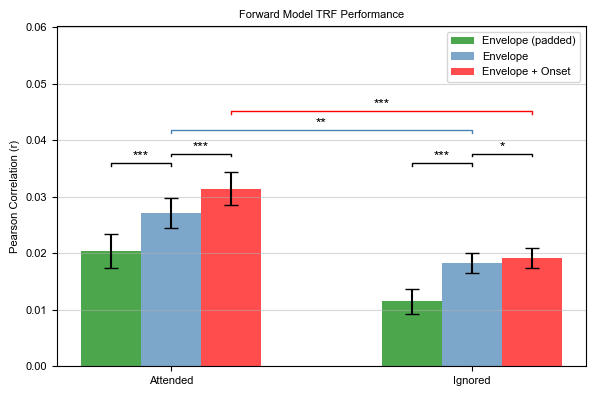

In [39]:
def plot_forward_model_summary(r, n_subjects):
    
    att_pad       = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, True)
    ign_pad       = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, True)
    att_env       = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False)
    ign_env       = helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,                                  ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False)
    att_env_onset = helper_functions.get_trf_model_name([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.ATTENDED, MODEL_TYPE.FORWARD, False)
    ign_env_onset = helper_functions.get_trf_model_name([PREDICTOR_TYPE.ENVELOPE, PREDICTOR_TYPE.ENVELOPE_ONSET], ATTENTION_TYPE.IGNORED,  MODEL_TYPE.FORWARD, False)

    conditions = [att_pad, ign_pad, att_env, ign_env, att_env_onset, ign_env_onset]
    mean_vals  = {name: np.mean(r[name]) for name in conditions}
    sem_vals   = {name: stats.sem(r[name])  for name in conditions}

    tests = {
        'att_vs_pad':           stats.ttest_rel(r[att_env],       r[att_pad]),
        'ign_vs_pad':           stats.ttest_rel(r[ign_env],       r[ign_pad]),
        'att_vs_ign':           stats.ttest_rel(r[att_env],       r[ign_env]),
        'att_env_vs_env_onset': stats.ttest_rel(r[att_env],       r[att_env_onset]),
        'ign_env_vs_env_onset': stats.ttest_rel(r[ign_env],       r[ign_env_onset]),
        'att_vs_ign_env_onset': stats.ttest_rel(r[att_env_onset], r[ign_env_onset]),
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    x, width = np.arange(2), 0.2

    bar_groups = [
        (att_pad,       ign_pad,       0,        'green',     'Envelope (padded)'),
        (att_env,       ign_env,       +width,   'steelblue', 'Envelope'),
        (att_env_onset, ign_env_onset, +2*width, 'red',       'Envelope + Onset'),
    ]

    for att_key, ign_key, offset, color, label in bar_groups:
        vals = [mean_vals[att_key], mean_vals[ign_key]]
        sems = [sem_vals[att_key],  sem_vals[ign_key]]
        ax.bar(x + offset, vals, width, yerr=sems, capsize=5, color=color, alpha=0.7, label=label)

    y_max = max(mean_vals[k] + sem_vals[k] for k in conditions)

    # Padded vs unpadded
    helper_functions.add_sig_line(ax, 0,       width,     y_max + 0.030 * y_max, helper_functions.sig_marker(tests['att_vs_pad'][1]))
    helper_functions.add_sig_line(ax, 1,       1+width,   y_max + 0.030 * y_max, helper_functions.sig_marker(tests['ign_vs_pad'][1]))

    # Envelope vs envelope+onset
    helper_functions.add_sig_line(ax, width,   2*width,   y_max + 0.080 * y_max, helper_functions.sig_marker(tests['att_env_vs_env_onset'][1]))
    helper_functions.add_sig_line(ax, 1+width, 1+2*width, y_max + 0.080 * y_max, helper_functions.sig_marker(tests['ign_env_vs_env_onset'][1]))

    # Attended vs ignored per condition
    helper_functions.add_sig_line(ax, width,   1+width,   y_max + 0.200 * y_max, helper_functions.sig_marker(tests['att_vs_ign'][1]),           color='steelblue')
    helper_functions.add_sig_line(ax, 2*width, 1+2*width, y_max + 0.30 * y_max, helper_functions.sig_marker(tests['att_vs_ign_env_onset'][1]), color='red')

    ax.set_xticks(x + width)
    ax.set_xticklabels(['Attended', 'Ignored'])
    ax.set_ylabel('Pearson Correlation (r)')
    ax.set_title('Forward Model TRF Performance')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.5)
    ax.set_ylim(0, y_max * 1.75)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'forward_model_bar_plot.png', bbox_inches='tight')
    plt.show()

    return mean_vals, sem_vals, tests

mean_vals, sem_vals, tests = plot_forward_model_summary(r, n_subjects)

In [40]:
# %%
# LaTeX results summary
n = n_subjects - 1
print("% Results summary (LaTeX)")
print(r"\textbf{Mean correlation (r):}")
print(r"\begin{itemize}")
for name, val in mean_vals.items():
    print(r"  \item %s: $%.4f$" % (name.replace('_', ' '), val))
print(r"\end{itemize}")
print(r"\textbf{Statistical tests:}")
print(r"\begin{itemize}")
for label, (t, p) in tests.items():
    print(r"  \item %s: $t(%d) = %.2f$, $p = %.3g$" % (label.replace('_', ' '), n, t, p))
print(r"\end{itemize}")

% Results summary (LaTeX)
\textbf{Mean correlation (r):}
\begin{itemize}
  \item forward attended envelope padded: $0.0204$
  \item forward ignored envelope padded: $0.0115$
  \item forward attended envelope: $0.0271$
  \item forward ignored envelope: $0.0183$
  \item forward attended envelope+envelope onset: $0.0315$
  \item forward ignored envelope+envelope onset: $0.0192$
\end{itemize}
\textbf{Statistical tests:}
\begin{itemize}
  \item att vs pad: $t(17) = 5.40$, $p = 4.77e-05$
  \item ign vs pad: $t(17) = 4.48$, $p = 0.000332$
  \item att vs ign: $t(17) = 3.64$, $p = 0.00203$
  \item att env vs env onset: $t(17) = -4.90$, $p = 0.000135$
  \item ign env vs env onset: $t(17) = -2.13$, $p = 0.0481$
  \item att vs ign env onset: $t(17) = 4.83$, $p = 0.000157$
\end{itemize}
